In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['species'] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Count:")
print(df['species'].value_counts())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Species Count:
species
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
# Display species names

print("Target Names:", iris.target_names)

# Replace numeric values with species names
df['species_name'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df[['species', 'species_name']].head()

Target Names: ['setosa' 'versicolor' 'virginica']


,species,species_name
0,0,setosa
1,0,setosa
2,0,setosa
3,0,setosa
4,0,setosa


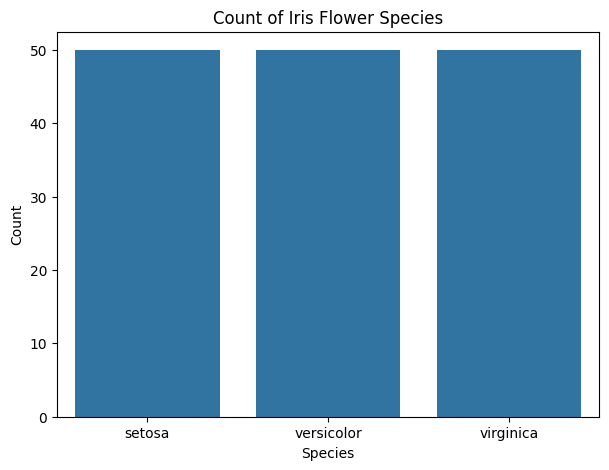

In [ ]:
# Visualize the number of flowers in each species

plt.figure(figsize=(7,5))

sns.countplot(data=df, x='species_name')

plt.title('Count of Iris Flower Species')
plt.xlabel('Species')
plt.ylabel('Count')

plt.show()

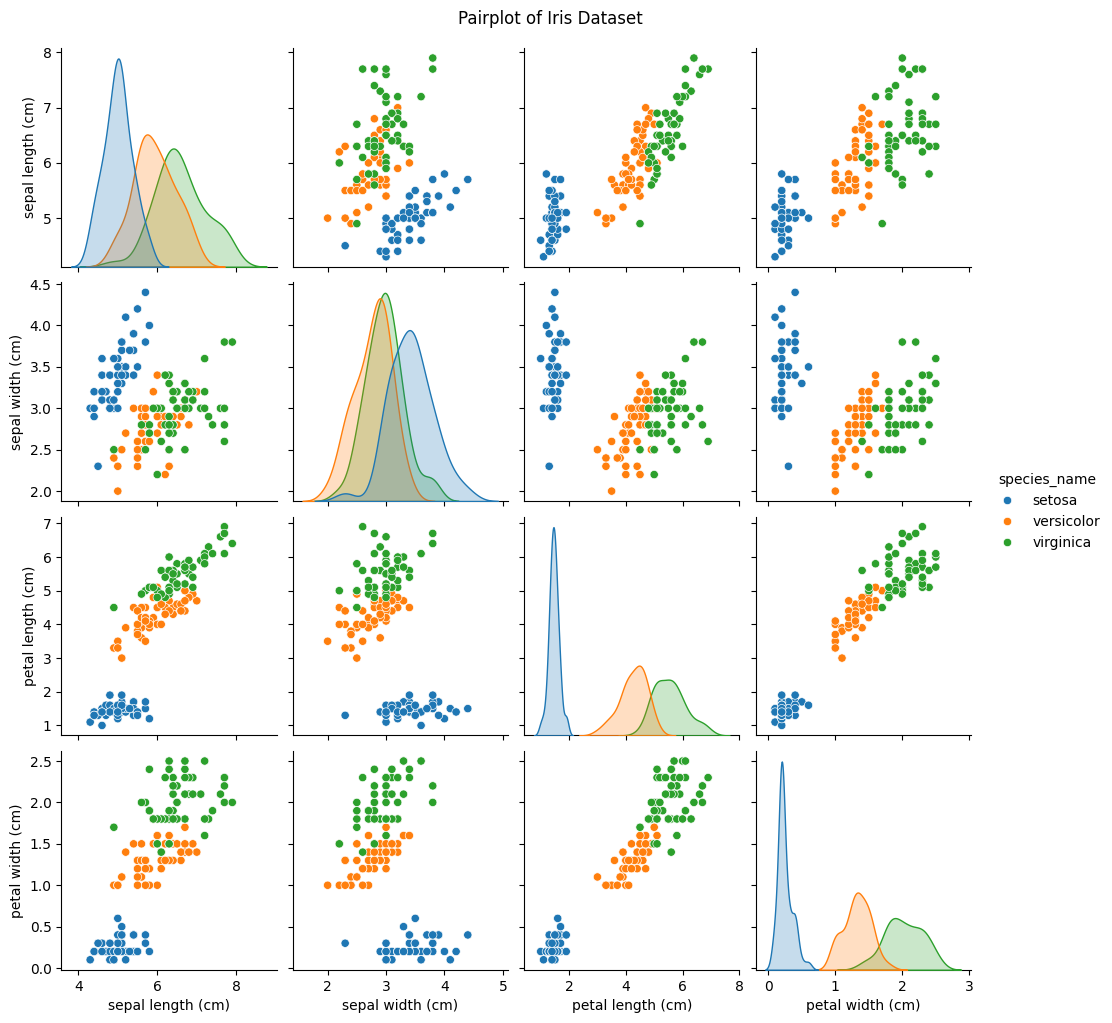

In [ ]:
# Pairplot to visualize relationships between features

sns.pairplot(
    df,
    vars=iris.feature_names,
    hue='species_name'
)

plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

In [ ]:
# Separate features and target

X = df[iris.feature_names]
y = df['species']

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [ ]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [ ]:
# Create and train the KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [ ]:
# Make predictions

y_pred = knn_model.predict(X_test_scaled)

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("KNN Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

KNN Model Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



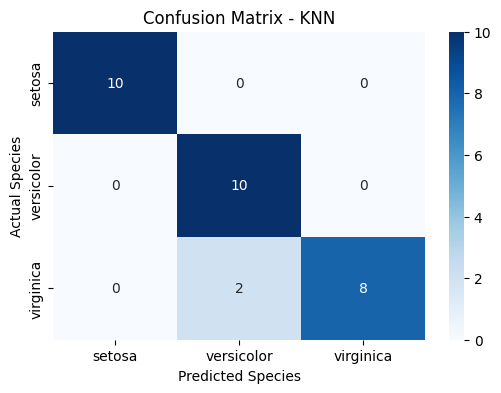

In [ ]:
# Evaluate the model

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix - KNN')
plt.show()

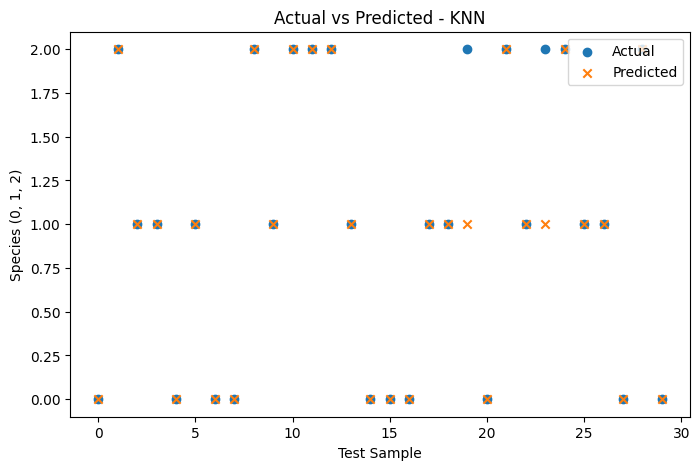

In [ ]:
# Compare actual and predicted species

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, label='Actual', marker='o')
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', marker='x')

plt.xlabel('Test Sample')
plt.ylabel('Species (0, 1, 2)')
plt.title('Actual vs Predicted - KNN')
plt.legend()
plt.show()

In [ ]:
# Train Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Model Accuracy:", dt_accuracy)
print("Accuracy Percentage:", dt_accuracy * 100, "%")

Decision Tree Model Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


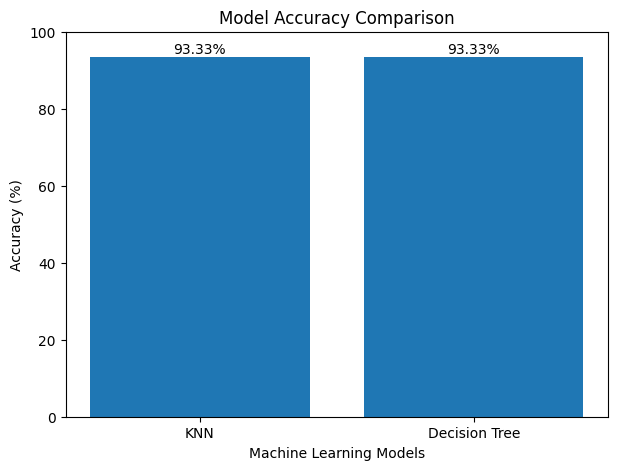

In [ ]:
# Compare model accuracies

models = ['KNN', 'Decision Tree']
accuracies = [accuracy * 100, dt_accuracy * 100]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.show()


## Conclusion

In this project, the Iris flower classification task was performed using machine learning techniques.

The Iris dataset contains 150 samples from three flower species: Setosa, Versicolor, and Virginica. Data visualization and preprocessing were performed before training the models.

Two classification models, K-Nearest Neighbors (KNN) and Decision Tree, were trained and evaluated. Both models achieved an accuracy of 93.33% on the test dataset.

The results show that machine learning models can effectively classify Iris flower species based on their sepal and petal measurements.
